In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
data = pd.read_csv("amazon_sales_dataset.csv")

In [4]:
df = data.copy()

In [5]:
df.shape

(50000, 13)

In [6]:
df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          50000 non-null  int64  
 1   order_date        50000 non-null  str    
 2   product_id        50000 non-null  int64  
 3   product_category  50000 non-null  str    
 4   price             50000 non-null  float64
 5   discount_percent  50000 non-null  int64  
 6   quantity_sold     50000 non-null  int64  
 7   customer_region   50000 non-null  str    
 8   payment_method    50000 non-null  str    
 9   rating            50000 non-null  float64
 10  review_count      50000 non-null  int64  
 11  discounted_price  50000 non-null  float64
 12  total_revenue     50000 non-null  float64
dtypes: float64(4), int64(5), str(4)
memory usage: 5.0 MB


In [8]:
df.isnull().sum()

order_id            0
order_date          0
product_id          0
product_category    0
price               0
discount_percent    0
quantity_sold       0
customer_region     0
payment_method      0
rating              0
review_count        0
discounted_price    0
total_revenue       0
dtype: int64

==> no null values

delete unimportant columns

In [9]:
df = df.drop(['order_id', 'order_date', 'product_id'], axis=1)
df.head()

,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


split the target column

In [10]:
target = df['rating']
df = df.drop(['rating'], axis=1)
df.head(0)


,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,review_count,discounted_price,total_revenue


working on categorical columns

In [11]:
dfc = df.select_dtypes(include=['object'])
dfc.head()

C:\Users\pc\AppData\Local\Temp\ipykernel_16584\373878922.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  dfc = df.select_dtypes(include=['object'])


,product_category,customer_region,payment_method
0,Books,North America,UPI
1,Fashion,Asia,Credit Card
2,Sports,Europe,UPI
3,Books,Middle East,UPI
4,Beauty,Middle East,UPI


In [12]:
dfc.describe(include=object)

C:\Users\pc\AppData\Local\Temp\ipykernel_16584\184576087.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  dfc.describe(include=object)


,product_category,customer_region,payment_method
count,50000,50000,50000
unique,6,4,5
top,Beauty,Asia,Wallet
freq,8465,12526,10106


check the unimportant categorical columns

In [13]:
from pandas.plotting import table
from scipy.stats import chi2_contingency

cat_cols = dfc.select_dtypes(include='uint8').columns

valid_cat_cols = []
for col in cat_cols:
    if X[col].sum() > 0:
        valid_cat_cols.append(col)

cat_cols = valid_cat_cols

chi2_res = []

for col in cat_cols:
    table = pd.crosstab(dfc[col], target)

    if table.shape[0] > 1 and table.shape[1] > 1:
        chi2_stat, p, dof, ex = chi2_contingency(table)
        chi2_res.append((col, p))

chi2 = pd.DataFrame(chi2_res, columns=['feature', 'p'])

drop_cat_cols = chi2[chi2['p'] > 0.05]['feature'].tolist()

cols_drop =  drop_cat_cols
dfc = dfc.drop(columns=cols_drop , errors="ignore")


In [14]:
cols_drop

[]

==> no unimportant categorical columns

In [15]:
print(dfc.product_category.value_counts(),"\n\n", dfc.customer_region.value_counts(),"\n\n",  dfc.payment_method.value_counts())

product_category
Beauty            8465
Fashion           8365
Books             8327
Electronics       8320
Sports            8265
Home & Kitchen    8258
Name: count, dtype: int64 

 customer_region
Asia             12526
North America    12517
Middle East      12505
Europe           12452
Name: count, dtype: int64 

 payment_method
Wallet              10106
UPI                 10078
Debit Card           9981
Cash on Delivery     9927
Credit Card          9908
Name: count, dtype: int64


In [16]:
# encoding the columns
dfc= pd.get_dummies(dfc)
dfc.head()

,product_category_Beauty,product_category_Books,product_category_Electronics,product_category_Fashion,product_category_Home & Kitchen,product_category_Sports,customer_region_Asia,customer_region_Europe,customer_region_Middle East,customer_region_North America,payment_method_Cash on Delivery,payment_method_Credit Card,payment_method_Debit Card,payment_method_UPI,payment_method_Wallet
0,False,True,False,False,False,False,False,False,False,True,False,False,False,True,False
1,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False
2,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False
3,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False
4,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False


working on numerical columns

In [17]:
dfn = df.select_dtypes(include=['int64','float64'])
dfn.head()

,price,discount_percent,quantity_sold,review_count,discounted_price,total_revenue
0,128.75,10,4,443,115.88,463.52
1,302.60,20,5,475,242.08,1210.40
2,495.80,20,2,183,396.64,793.28
3,371.95,15,4,212,316.16,1264.64
4,201.68,0,4,308,201.68,806.72


In [18]:
dfn.describe()

,price,discount_percent,quantity_sold,review_count,discounted_price,total_revenue
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,252.507260,13.340700,2.999400,249.329280,218.886566,657.331475
std,143.025544,9.850694,1.415401,144.251981,127.317681,526.223968
min,5.010000,0.000000,1.000000,0.000000,3.530000,3.840000
25%,127.840000,5.000000,2.000000,125.000000,109.680000,240.320000
50%,252.970000,10.000000,3.000000,250.000000,215.805000,505.410000
75%,376.335000,20.000000,4.000000,374.000000,322.702500,968.970000
max,499.990000,30.000000,5.000000,499.000000,499.910000,2499.550000


In [19]:
for col in dfn.columns:
    Q1 = dfn[col].quantile(0.25)
    Q3 = dfn[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    dfn = dfn[(dfn[col] >= lower_bound) & (dfn[col] <= upper_bound)]


In [20]:
# scalling the columns
for col in dfn.columns:
    dfn[col] = (df[col] - dfn[col].mean()) / dfn[col].std()

dfn.head()

,price,discount_percent,quantity_sold,review_count,discounted_price,total_revenue
0,-0.850891,-0.352777,0.734309,1.342233,-0.795551,-0.344697
1,0.376678,0.662567,1.446436,1.564053,0.212729,1.169925
2,1.740879,0.662567,-0.689945,-0.460054,1.447592,0.324034
3,0.866364,0.154895,0.734309,-0.259030,0.804594,1.279920
4,-0.335926,-1.368120,0.734309,0.406430,-0.110048,0.351289


In [21]:
u = pd.concat([dfn, target], axis=1)

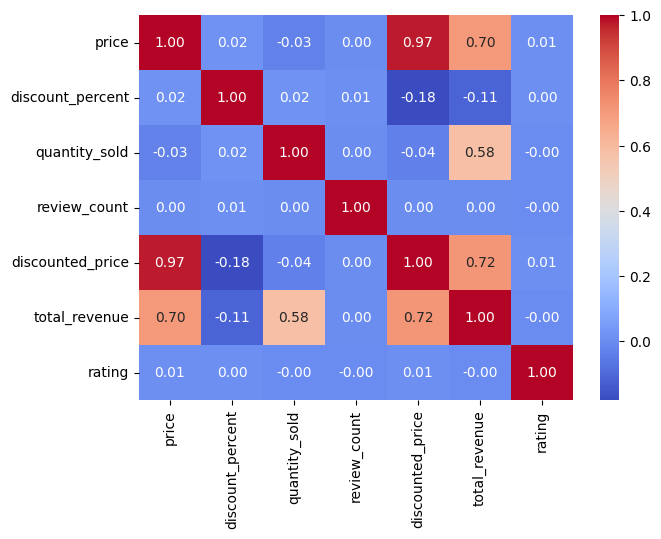

In [22]:
plt.figure(figsize=(7,5))
sns.heatmap(u.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

==> there is no correlations between the numerical data and the target column

In [23]:
mean = target.mean()
mean

np.float64(2.9963159999999998)

In [24]:
target[target < mean] = -1  # bad rating
target[target >= mean] = 1  # good rating

In [25]:
target.value_counts()

rating
 1.0    25510
-1.0    24490
Name: count, dtype: int64

In [26]:
X = dfc
# X = dfc
y = target

In [27]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X , y, test_size=0.20, random_state=42, stratify=y)

In [28]:
from sklearn.svm import SVC

model = SVC(kernel='rbf')

In [29]:
model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [30]:
model.score(X_test, y_test)

0.5137

In [31]:
y_pred_svc = model.predict(X_test)
y_pred_svc

array([-1., -1., -1., ...,  1.,  1.,  1.], shape=(10000,))

In [32]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_svc))

              precision    recall  f1-score   support

        -1.0       0.51      0.34      0.41      4898
         1.0       0.52      0.68      0.59      5102

    accuracy                           0.51     10000
   macro avg       0.51      0.51      0.50     10000
weighted avg       0.51      0.51      0.50     10000



comparing with logistic model

In [33]:
from sklearn.linear_model import LogisticRegression
model2 = LogisticRegression(max_iter=1000)

In [34]:
model2.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [35]:
y_pred_lr = model2.predict(X_test)
y_pred_lr

array([ 1.,  1., -1., ...,  1.,  1.,  1.], shape=(10000,))

In [36]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_lr))

              precision    recall  f1-score   support

        -1.0       0.50      0.15      0.23      4898
         1.0       0.51      0.85      0.64      5102

    accuracy                           0.51     10000
   macro avg       0.50      0.50      0.44     10000
weighted avg       0.50      0.51      0.44     10000



In [37]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_svc))

              precision    recall  f1-score   support

        -1.0       0.51      0.34      0.41      4898
         1.0       0.52      0.68      0.59      5102

    accuracy                           0.51     10000
   macro avg       0.51      0.51      0.50     10000
weighted avg       0.51      0.51      0.50     10000



comparing with randomForest model

In [38]:
from sklearn.ensemble import RandomForestClassifier

model3 = RandomForestClassifier(max_depth=5, n_estimators=100, random_state=42)
model3.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [39]:
y_pred_rf = model3.predict(X_test)
y_pred_rf

array([ 1.,  1., -1., ...,  1.,  1.,  1.], shape=(10000,))

In [40]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

        -1.0       0.52      0.11      0.19      4898
         1.0       0.51      0.90      0.65      5102

    accuracy                           0.51     10000
   macro avg       0.51      0.51      0.42     10000
weighted avg       0.51      0.51      0.42     10000



In [41]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_svc))

              precision    recall  f1-score   support

        -1.0       0.51      0.34      0.41      4898
         1.0       0.52      0.68      0.59      5102

    accuracy                           0.51     10000
   macro avg       0.51      0.51      0.50     10000
weighted avg       0.51      0.51      0.50     10000

